# TP4 — Summary: filtering, epoching and ERP averaging

This notebook combines the stimulus-onset detection from **TP2** and the EEG filtering from **TP3** into a single pipeline:

1. notch (50 Hz) + band-pass (4-40 Hz) filtering of the 8 EEG channels
2. detection of stimulus onsets from the digital trigger channel
3. epoching the filtered signals around each onset
4. baseline correction
5. plotting the grand-average ERP for each electrode

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

os.chdir('D:/DATA/Projets/M1_EEG_Project/')

# --- analysis parameters ---
fs = 250                     # sampling rate (Hz)
notch_freq, notch_q = 50, 30 # mains noise notch filter
band_low, band_high = 4, 40  # band-pass range (Hz)
pre, post = 125, 125         # samples kept before / after onset (0.5 s each, at 250 Hz)
electrode_cols = range(1, 9) # columns 1-8 hold the 8 EEG channels

# get current working directory

print("Current working directory:", os.getcwd())


# the data is a directory named 'data' in my current working directory
data = pd.read_csv('data/auditory_test.csv', delimiter='\t', header=None)


Current working directory: D:\DATA\Projets\M1_EEG_Project


the variables of interest are col.1 to 8 for eeg signal / and col. 13 for digital pulses indicating stimulus timing

First Step : filter

In [46]:
from scipy.signal import iirnotch, filtfilt, butter

data_filtered = []

for electrode in electrode_cols:
    raw = data[electrode].to_numpy()

    b, a = iirnotch(notch_freq, notch_q, fs)
    notched = filtfilt(b, a, raw)

    b, a = butter(4, [band_low / (fs / 2), band_high / (fs / 2)], btype='band')
    bandpassed = filtfilt(b, a, notched)

    data_filtered.append(bandpassed)


detection of stimulus onsets


In [47]:
stim = data[13].to_numpy()
onsets = np.where(np.diff(stim) > 0)[0] + 1
n_trials = len(onsets)
print(f"{n_trials} stimulus onsets detected")


120 stimulus onsets detected


now we align the eeg signals on the stim onsets, for each trial and each electrode.
we build a 3D array of shape (n_trials, pre+post, n_electrodes): n_trials trials x (125 samples before onset + 125 samples after) x 8 electrodes.

In [48]:
n_electrodes = len(data_filtered)
window = pre + post

data3D = np.zeros((n_trials, window, n_electrodes))

for electrode in range(n_electrodes):
    for i, onset in enumerate(onsets):
        data3D[i, :, electrode] = data_filtered[electrode][onset - pre:onset + post]


baseline correction: for each trial and electrode, we subtract the mean amplitude of the pre-stimulus baseline (the `pre` samples before onset), so that ERPs start at ~0 µV at stimulus onset.

In [49]:
baseline = data3D[:, :pre, :].mean(axis=1, keepdims=True)
data3D_bc = data3D - baseline


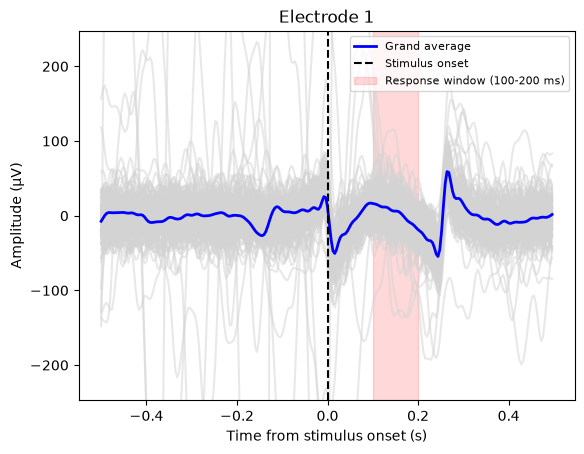

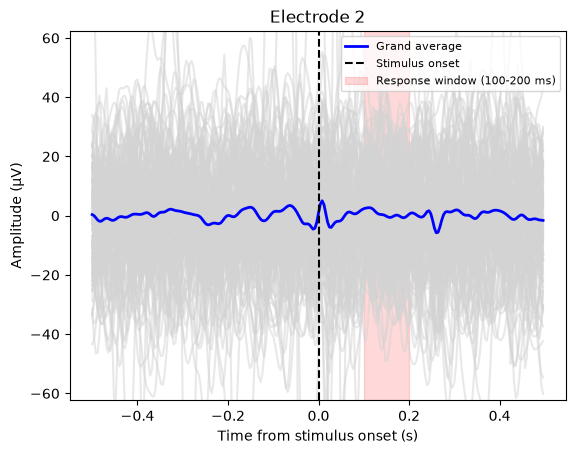

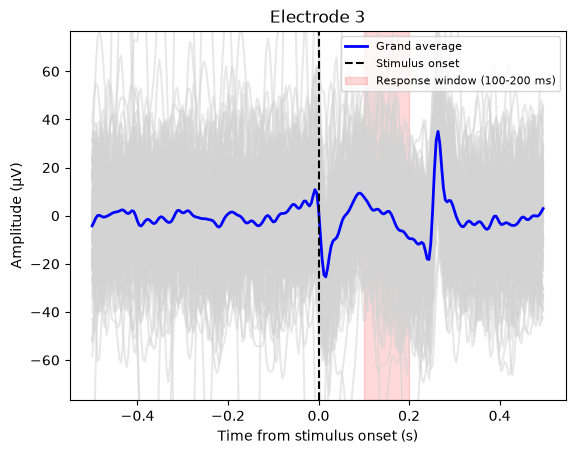

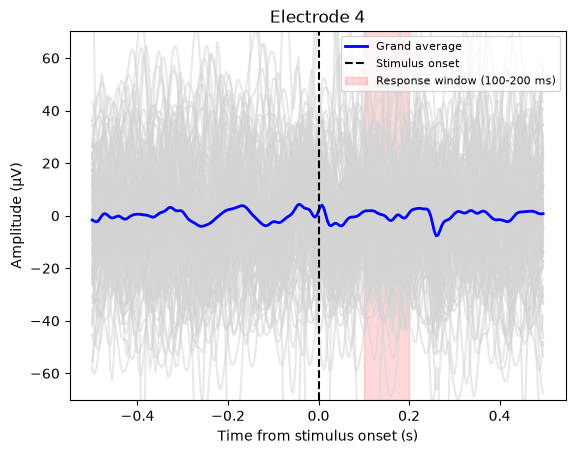

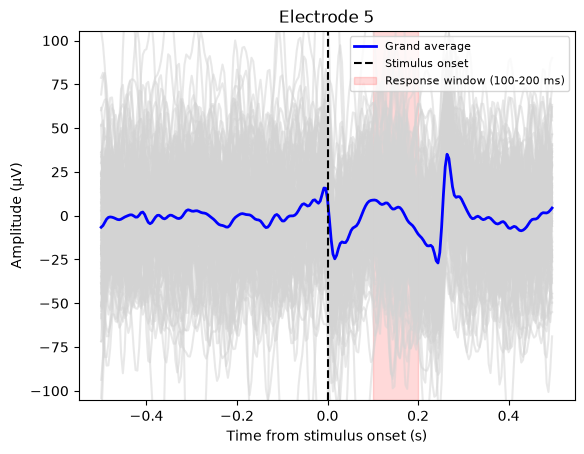

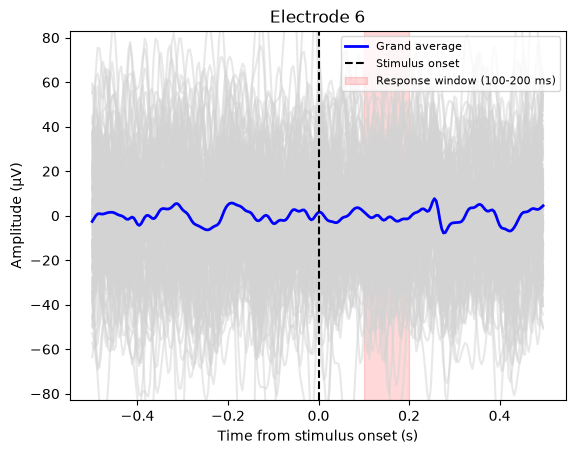

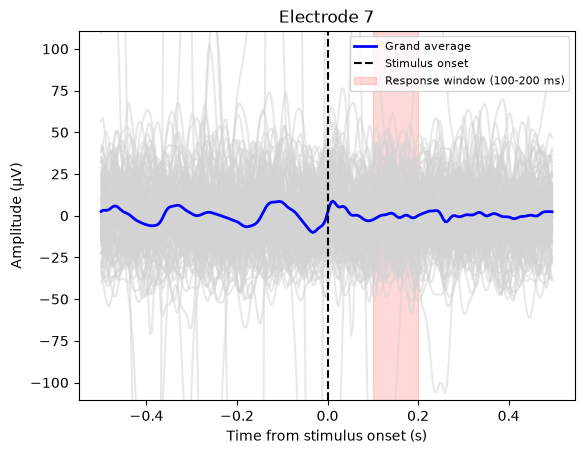

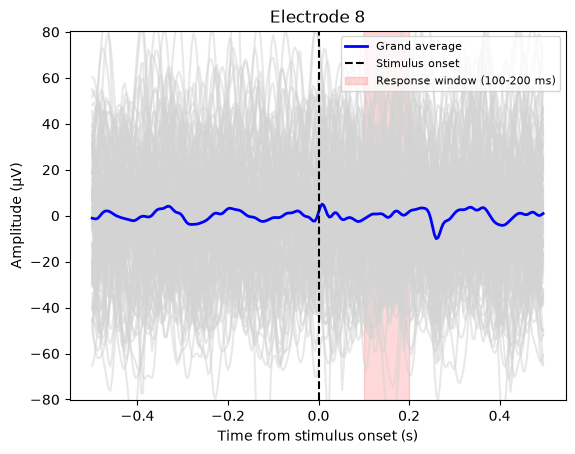

In [50]:
time = np.arange(-pre, post) / fs  # time axis in seconds relative to onset

for electrode in range(n_electrodes):
    erp = data3D_bc[:, :, electrode]
    grand_avg = erp.mean(axis=0)
    ylim = np.percentile(np.abs(erp), 99) * 1.2  # robust limit, avoids clipping by a fixed scale

    plt.figure()
    plt.plot(time, erp.T, color='lightgray', alpha=0.5)
    plt.plot(time, grand_avg, color='blue', linewidth=2, label='Grand average')
    plt.axvline(0, color='k', linestyle='--', label='Stimulus onset')
    plt.axvspan(0.1, 0.2, color='red', alpha=0.15, label='Response window (100-200 ms)')
    plt.title(f'Electrode {electrode + 1}')
    plt.xlabel('Time from stimulus onset (s)')
    plt.ylabel('Amplitude (µV)')
    plt.ylim(-ylim, ylim)
    plt.legend(loc='upper right', fontsize=8)
    plt.show()


another way to visualize the data on a signel figure with subplots for each electrode:

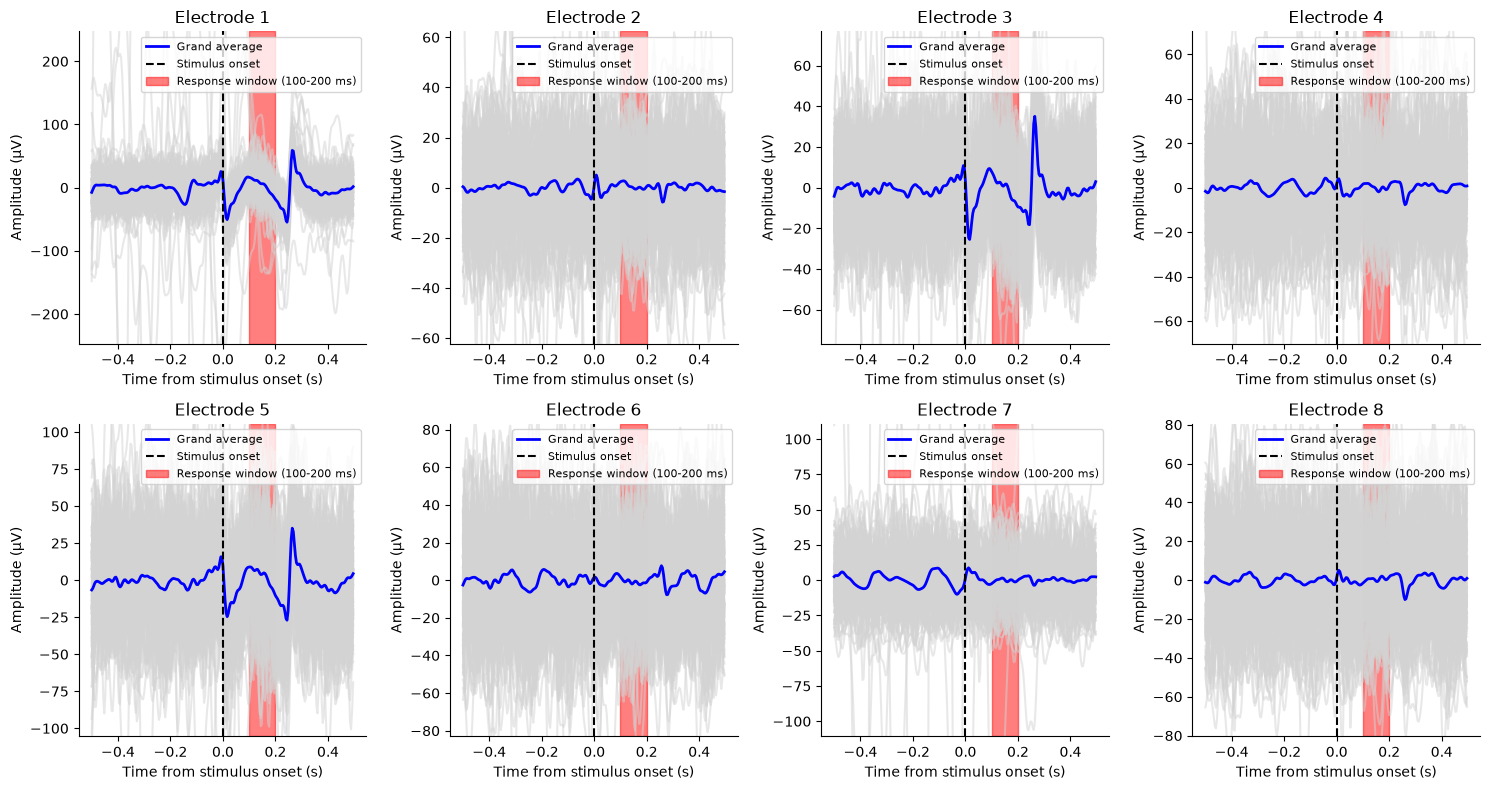

In [44]:
time = np.arange(-pre, post) / fs  # time axis in seconds relative to onset

fig,ax = plt.subplots(nrows=2, ncols=4, figsize=(15, 8))
ax = ax.flatten()

for electrode in range(n_electrodes):
    erp = data3D_bc[:, :, electrode]
    grand_avg = erp.mean(axis=0)
    ylim = np.percentile(np.abs(erp), 99) * 1.2  # robust limit, avoids clipping by a fixed scale

    ax[electrode].plot(time, erp.T, color='lightgray', alpha=0.5)
    ax[electrode].plot(time, grand_avg, color='blue', linewidth=2, label='Grand average')
    ax[electrode].axvline(0, color='k', linestyle='--', label='Stimulus onset')
    ax[electrode].axvspan(0.1, 0.2, color='red', alpha=0.5, label='Response window (100-200 ms)')
    ax[electrode].set_title(f'Electrode {electrode + 1}')
    ax[electrode].set_xlabel('Time from stimulus onset (s)')
    ax[electrode].set_ylabel('Amplitude (µV)')
    ax[electrode].set_ylim(-ylim, ylim)
    ax[electrode].legend(loc='upper right', fontsize=8)
    ax[electrode].spines['top'].set_visible(False)
    ax[electrode].spines['right'].set_visible(False)

plt.tight_layout()